## Initial Setup
Import dependencies and initialize components

In [7]:
from BitcoinLLMQA_utils import (
    fetch_bitcoin_price,
    update_dataset,
    analyze_data,
    setup_docsgpt,
    handle_query,
    setup_docsgpt
)
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import datetime

In [8]:
# Initialize LLM
llm = setup_docsgpt()

llama_model_load_from_file_impl: using device Metal (Apple M3) - 10922 MiB free
llama_model_loader: loaded meta data with 19 key-value pairs and 291 tensors from llama-2-7b-chat.Q4_K_M.gguf (version GGUF V2)
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = LLaMA v2
llama_model_loader: - kv   2:                       llama.context_length u32              = 4096
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 11008
llama_model_loader: - kv   6:                 llama.rope.dimension_count u32              = 128
llama_model_

## Real-time Data Collection Simulation
Run for 3 intervals (15 minutes total)

In [9]:
for i in range(3):
    clear_output(wait=True)
    print(f"Data Collection Cycle {i+1}/3")
    
    # Fetch and update data
    price = fetch_bitcoin_price()
    if price:
        df = update_dataset(price)
        metrics = analyze_data(df)
        
        # Display latest metrics
        display(metrics['hourly_avg'].tail(1))
        
        # Simple progress bar
        print("[" + "="*(i+1) + " "*(3-(i+1)) + "]")
    
    time.sleep(5)  # Reduced from 300s for demo


Data Collection Cycle 3/3
Saved price: 102655 | Volatility: 0.0011759067396684103


,price,volatility
timestamp,,
2025-04-24 18:00:00,93507.666667,0.001376


[===]


## Data Analysis & Visualization

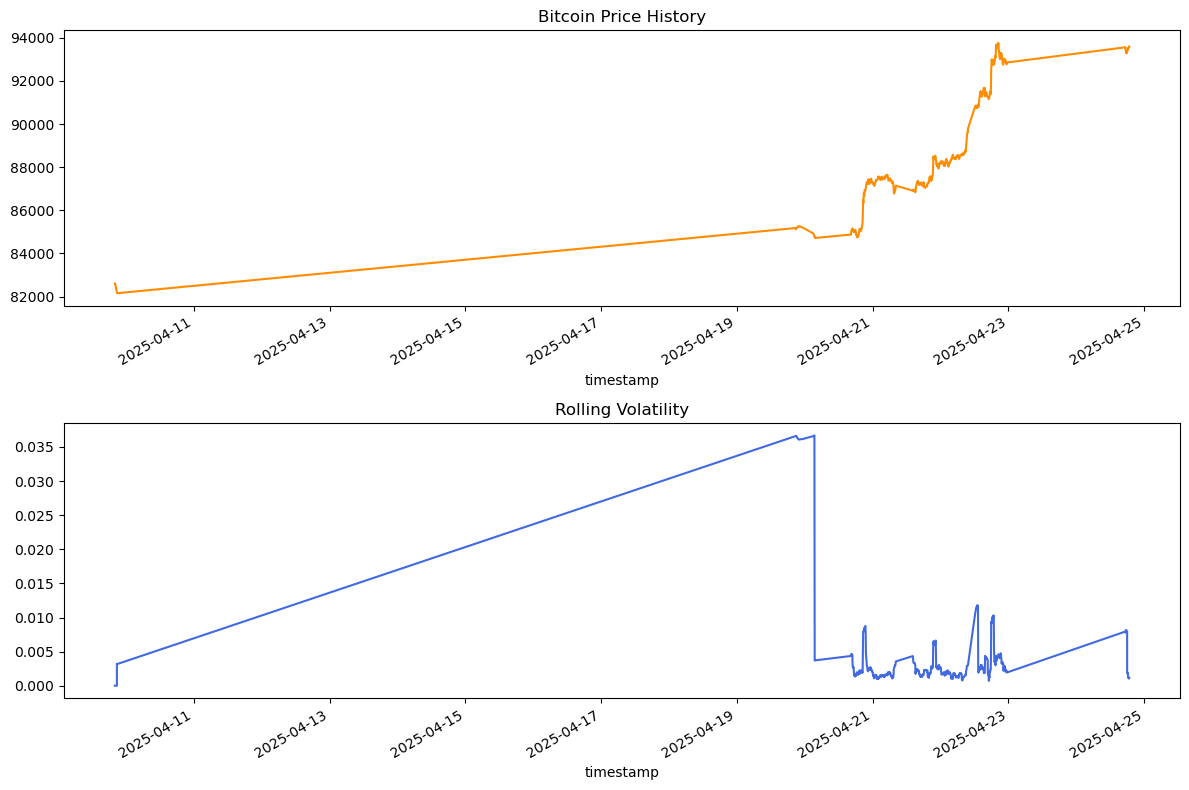

In [10]:
# Load complete dataset
full_df = pd.read_csv('bitcoin_prices.csv', parse_dates=['timestamp'])

# Generate analysis
metrics = analyze_data(full_df)

# Plot price and volatility
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
full_df.set_index('timestamp')['price'].plot(
    ax=ax[0], 
    title='Bitcoin Price History',
    color='darkorange'
)
full_df.set_index('timestamp')['volatility'].plot(
    ax=ax[1],
    title='Rolling Volatility',
    color='royalblue'
)
plt.tight_layout()
plt.show()

## Interactive Q&A System
Predefined example questions with enhanced output

In [11]:
questions = [
    "What was the highest price in the last 6 hours?",
    "Show me times when volatility spiked",
    "What's the current price trend?",
    "Exit"
]

for idx, question in enumerate(questions, 1):
    clear_output(wait=True)
    print(f"Question {idx}/{len(questions)}")
    print("="*30)
    
    if question == "Exit":
        break
        
    # Create context from data
    context = ""
    if "price" in question.lower():
        context = f"Recent Bitcoin prices:\n{full_df[['timestamp', 'price']].tail(12).to_string()}"
    elif "volatility" in question.lower():
        context = f"Volatility anomalies:\n{metrics['recent_anomalies'].tail(3).to_string()}"
    
    # Get answer with context
    answer = handle_query(llm, f"{context}\n{question}")
    
    # Print formatted output
    print(f"\nQ: {question}")
    print(f"\nA: {answer}\n")
    
    # Show supporting data
    if context:
        print("\nSupporting Data:")
        print(context)
    
    if idx < len(questions):
        input("\nPress Enter to continue...")


Question 4/4


## Advanced Query Demonstration
Custom question input with data context

In [12]:
user_question = input("Enter your Bitcoin data question: ")
context_df = full_df.tail(24).describe()  # Last 24 periods stats
answer = handle_query(llm, f"{user_question}\nContext:\n{context_df}")

print(f"\nAnswer: {answer}")

Llama.generate: 4 prefix-match hit, remaining 380 prompt tokens to eval
llama_perf_context_print:        load time =    9453.48 ms
llama_perf_context_print: prompt eval time =    7068.39 ms /   380 tokens (   18.60 ms per token,    53.76 tokens per second)
llama_perf_context_print:        eval time =    1578.95 ms /    22 runs   (   71.77 ms per token,    13.93 tokens per second)
llama_perf_context_print:       total time =    8650.33 ms /   402 tokens



Answer: The average Bitcoin price in the last 4 hours is around $9,3384.
